In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

from models.vqvae import VQVAE
from models.resnet import ResNet
from dataset.vae_dataset import VAEDataset

In [2]:
vqvae_checkpoint = 'weights/vqvae.ckpt'
resnet_checkpoint = 'weights/resnet.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_path = 'train.memmap'

In [4]:
vqvae = VQVAE.load_from_checkpoint(vqvae_checkpoint, in_channels=5).to(device)
vqvae.eval()

resnet = ResNet(in_channels=8).to(device)
resnet.load_state_dict(torch.load(resnet_checkpoint, weights_only=True))
resnet.eval()

dataset = VAEDataset(data_path, channels=5, img_res=(128, 64))

In [5]:
sample = torch.Tensor(dataset[0]).unsqueeze(0).to(device)
real = dataset[1]

with torch.no_grad():
    _, latent, _ = vqvae(sample)

    pred = resnet(latent)
    pred, _, _ = vqvae.quantize(pred)

    forecast = vqvae.decode(pred)

sample = sample.squeeze().cpu().numpy()
latent = latent.squeeze().cpu().numpy()
pred = pred.squeeze().cpu().numpy()
forecast = forecast.squeeze().cpu().numpy()

# mse between latent and pred
mse = np.mean((latent - pred) ** 2)
print(f'MSE between latent and pred: {mse}')


MSE between latent and pred: 0.03186039626598358


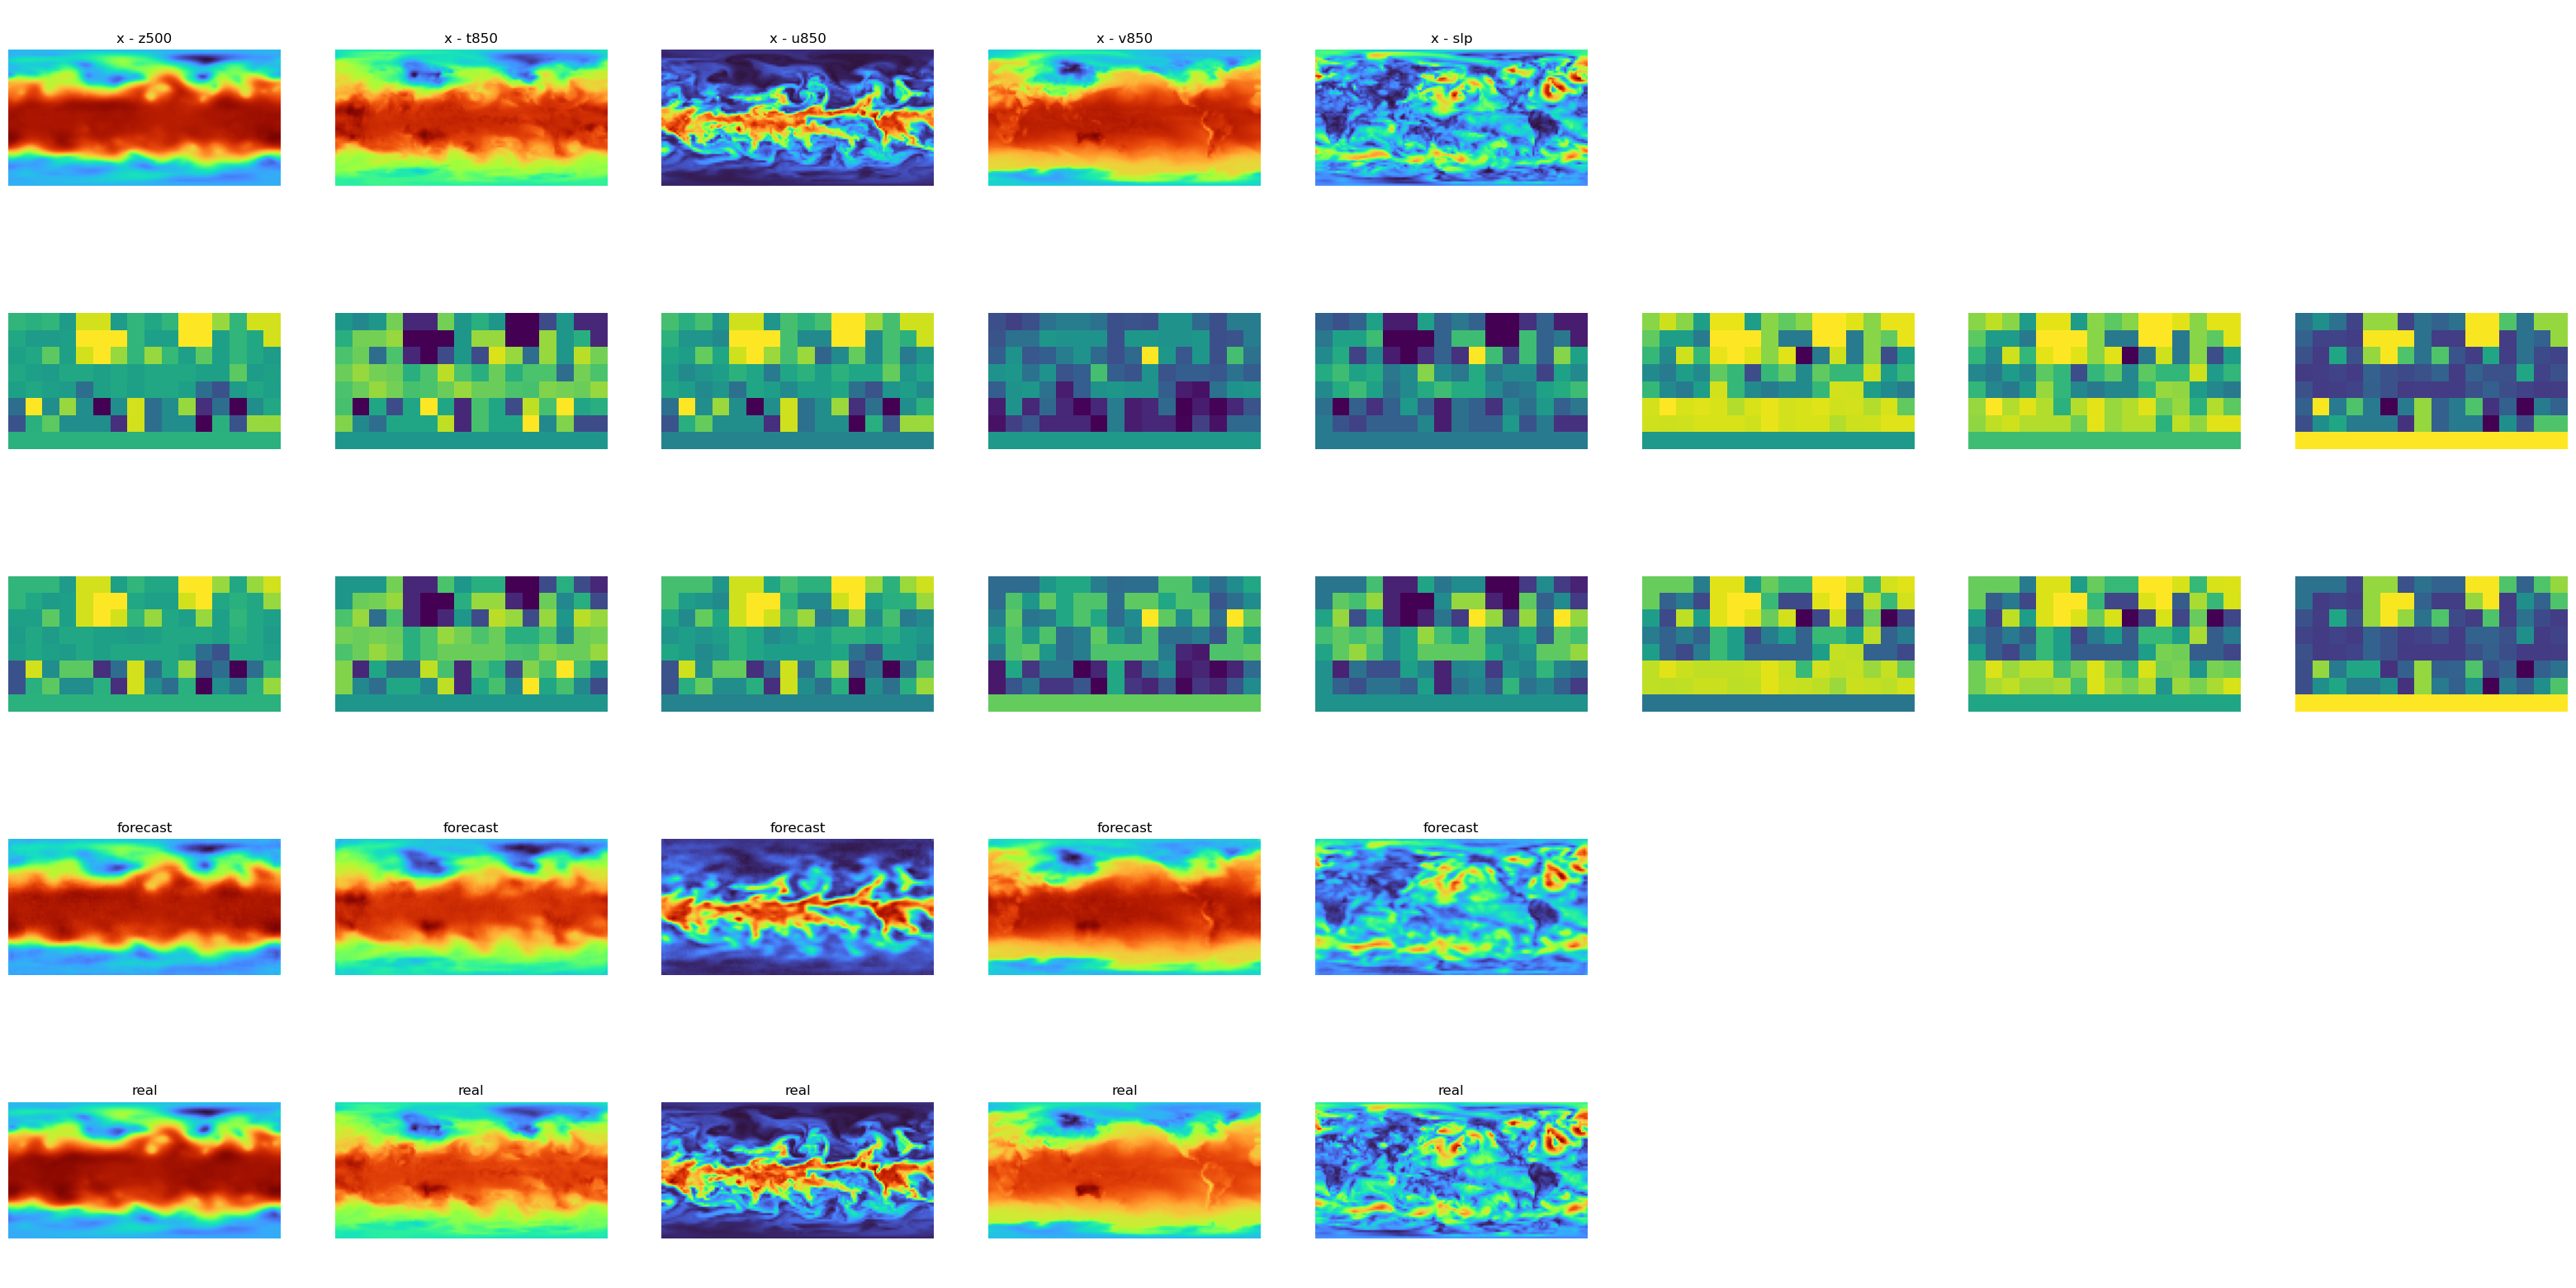

In [6]:
fig, axs = plt.subplots(5, 8, figsize=(40, 20))

axs[0, 0].imshow(sample[0].T, cmap='turbo', origin='lower')
axs[0, 0].set_title('x - z500')
axs[0, 0].axis('off')

axs[0, 1].imshow(sample[1].T, cmap='turbo', origin='lower')
axs[0, 1].set_title('x - t850')
axs[0, 1].axis('off')

axs[0, 2].imshow(sample[2].T, cmap='turbo', origin='lower')
axs[0, 2].set_title('x - u850')
axs[0, 2].axis('off')

axs[0, 3].imshow(sample[3].T, cmap='turbo', origin='lower')
axs[0, 3].set_title('x - v850')
axs[0, 3].axis('off')

axs[0, 4].imshow(sample[4].T, cmap='turbo', origin='lower')
axs[0, 4].set_title('x - slp')
axs[0, 4].axis('off')

axs[0, 5].axis('off')
axs[0, 6].axis('off')
axs[0, 7].axis('off')

for i in range(8):
    axs[1, i].imshow(latent[i].T, origin='lower')
    axs[1, i].set_title('')
    axs[1, i].axis('off')

for i in range(8):
    axs[2, i].imshow(pred[i].T, origin='lower')
    axs[2, i].set_title('')
    axs[2, i].axis('off')

for i in range(5):
    axs[3, i].imshow(forecast[i].T, cmap='turbo', origin='lower')
    axs[3, i].set_title('forecast')
    axs[3, i].axis('off')

for i in range(3):
    axs[3, i + 5].axis('off')

for i in range(5):
    axs[4, i].imshow(real[i].T, cmap='turbo', origin='lower')
    axs[4, i].set_title('real')
    axs[4, i].axis('off')

for i in range(3):
    axs[4, i + 5].axis('off')



plt.savefig('forecast.png')
plt.show()

